In [2]:
import seaborn
import pandas as pd
import numpy as np

In [3]:
seaborn.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
dataframe = seaborn.load_dataset('penguins')

In [5]:
dataframe.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
species_names = pd.unique(dataframe['species'])

In [7]:
species_names

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [8]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [9]:
dataframe.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [10]:
from sklearn.preprocessing import OrdinalEncoder

In [11]:
model_ordinal = OrdinalEncoder()

In [13]:
dataframe.select_dtypes(['object']).columns

Index(['species', 'island', 'sex'], dtype='object')

In [14]:
transf_values = model_ordinal.fit_transform(dataframe.select_dtypes(['object']))

In [15]:
transf_values

array([[0., 2., 1.],
       [0., 2., 0.],
       [0., 2., 0.],
       ...,
       [2., 0., 1.],
       [2., 0., 0.],
       [2., 0., 1.]])

In [16]:
dataframe[dataframe.select_dtypes(['object']).columns] = transf_values

In [17]:
dataframe

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,2.0,39.1,18.7,181.0,3750.0,1.0
1,0.0,2.0,39.5,17.4,186.0,3800.0,0.0
2,0.0,2.0,40.3,18.0,195.0,3250.0,0.0
3,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,0.0,2.0,36.7,19.3,193.0,3450.0,0.0
...,...,...,...,...,...,...,...
339,2.0,0.0,NaN,NaN,NaN,NaN,NaN
340,2.0,0.0,46.8,14.3,215.0,4850.0,0.0
341,2.0,0.0,50.4,15.7,222.0,5750.0,1.0
342,2.0,0.0,45.2,14.8,212.0,5200.0,0.0


In [18]:
dataframe.fillna(dataframe.mean(), inplace=True)

In [19]:
dataframe.dropna(inplace=True)

In [20]:
dataframe.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [21]:
x = dataframe.drop(['species'], axis=1)

In [22]:
x

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2.0,39.10000,18.70000,181.000000,3750.000000,1.000000
1,2.0,39.50000,17.40000,186.000000,3800.000000,0.000000
2,2.0,40.30000,18.00000,195.000000,3250.000000,0.000000
3,2.0,43.92193,17.15117,200.915205,4201.754386,0.504505
4,2.0,36.70000,19.30000,193.000000,3450.000000,0.000000
...,...,...,...,...,...,...
339,0.0,43.92193,17.15117,200.915205,4201.754386,0.504505
340,0.0,46.80000,14.30000,215.000000,4850.000000,0.000000
341,0.0,50.40000,15.70000,222.000000,5750.000000,1.000000
342,0.0,45.20000,14.80000,212.000000,5200.000000,0.000000


In [23]:
y = dataframe['species']

In [24]:
y

,species
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
339,2.0
340,2.0
341,2.0
342,2.0


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
model_random = RandomForestClassifier(n_estimators=5, max_depth=6)

In [30]:
model_random.fit(x_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=5)

In [31]:
y_pred = model_random.predict(x_test)

In [32]:
y_pred_prob = model_random.predict_proba(x_test)

In [33]:
y_pred_prob[3]

array([0.22, 0.78, 0.  ])

In [35]:
model_random.estimators_[3]

DecisionTreeClassifier(max_depth=6, max_features='sqrt', random_state=575684557)

In [36]:
from sklearn.tree import plot_tree, export_graphviz

In [37]:
import graphviz

[Text(0.5714285714285714, 0.9285714285714286, 'flipper_length_mm <= 206.5\ngini = 0.615\nsamples = 163\nvalue = [131, 44, 100]\nclass = Adelie'),
 Text(0.42857142857142855, 0.7857142857142857, 'bill_length_mm <= 46.2\ngini = 0.385\nsamples = 98\nvalue = [128, 40, 3]\nclass = Adelie'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.35714285714285715, 0.6428571428571429, 'sex <= 0.752\ngini = 0.137\nsamples = 75\nvalue = [128, 7, 3]\nclass = Adelie'),
 Text(0.2857142857142857, 0.5, 'flipper_length_mm <= 199.958\ngini = 0.25\nsamples = 42\nvalue = [61.0, 7.0, 3.0]\nclass = Adelie'),
 Text(0.14285714285714285, 0.35714285714285715, 'body_mass_g <= 3337.5\ngini = 0.14\nsamples = 40\nvalue = [61, 5, 0]\nclass = Adelie'),
 Text(0.07142857142857142, 0.21428571428571427, 'gini = 0.0\nsamples = 19\nvalue = [32, 0, 0]\nclass = Adelie'),
 Text(0.21428571428571427, 0.21428571428571427, 'bill_length_mm <= 41.35\ngini = 0.251\nsamples = 21\nvalue = [29, 5, 0]\nclass = Adelie'),
 Text(0.142857142857

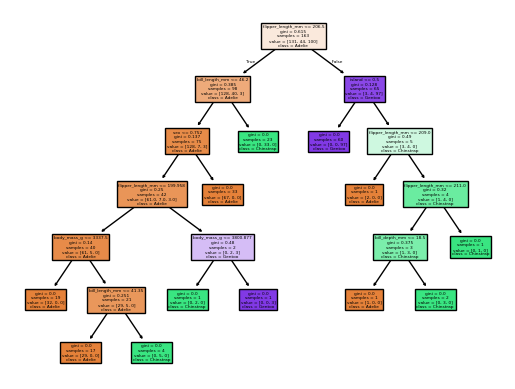

In [38]:
plot_tree(
    model_random.estimators_[3],
    feature_names=x.columns,
    class_names=species_names,
    filled=True
)

In [39]:
dot_data = export_graphviz(
    model_random.estimators_[3],
    feature_names=x.columns,
    class_names=species_names,
    filled=True
)

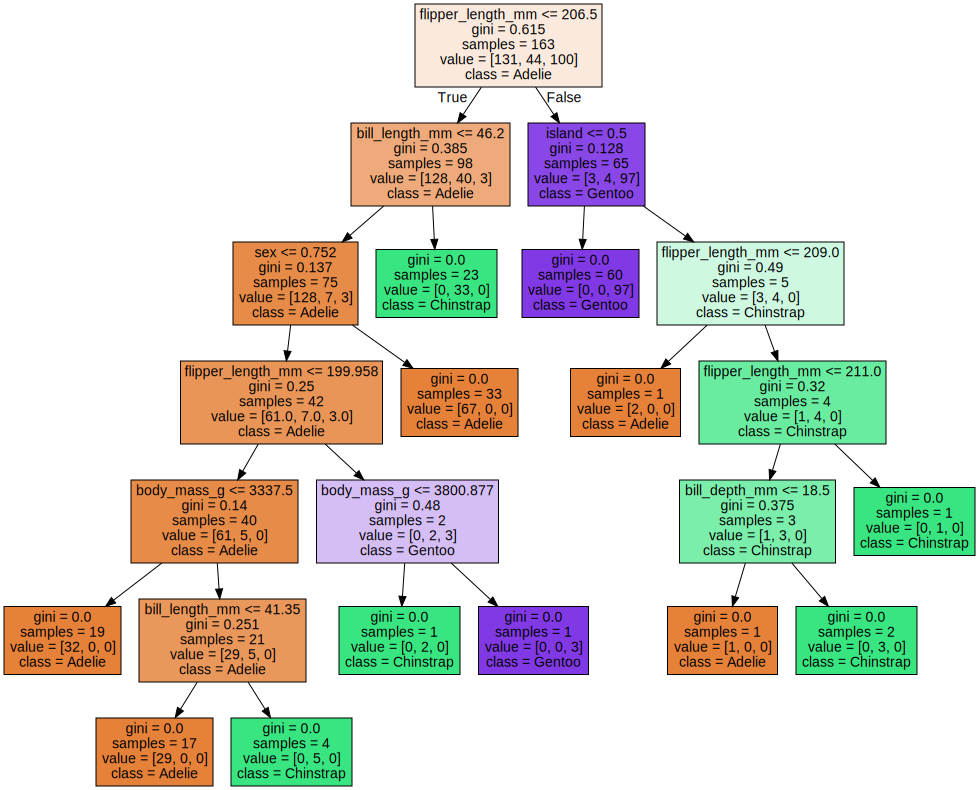

In [40]:
graph = graphviz.Source(dot_data, format="png")
graph

Regressão

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
X, y = make_regression(n_features=4, n_informative=2, random_state=0, shuffle=False)
regr = RandomForestRegressor(max_depth=2, random_state=0)
regr.fit(X, y)

RandomForestRegressor(max_depth=2, random_state=0)

In [42]:
print(regr.predict([[0, 0, 0, 0]]))

[-8.32987858]
